In [2]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



In [4]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

In [5]:
apps = apps.dropna()
apps = apps.drop_duplicates()

In [6]:
data = apps[['Rating', 'Reviews', 'Installs']].copy()

In [7]:
data['Installs'] = data['Installs'].str.replace('+','').str.replace(',','').astype(int)


In [8]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
apps['Cluster'] = kmeans.fit_predict(scaled_data)

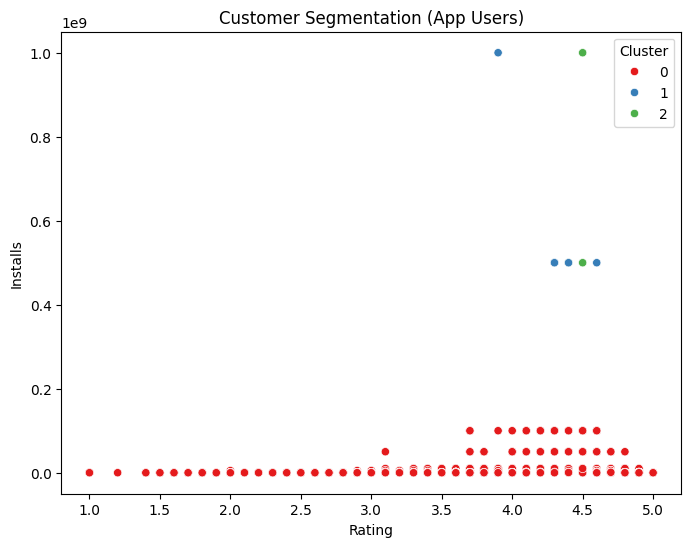

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data['Rating'], y=data['Installs'], hue=apps['Cluster'], palette='Set1')
plt.title("Customer Segmentation (App Users)")
plt.show()

In [12]:
# Clean the 'Installs' column properly
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')  # force convert to numbers

# Drop rows where conversion failed (NaN)
apps = apps.dropna(subset=['Installs'])

# Just to confirm
print(apps['Installs'].head(20))
print(apps['Installs'].dtype)


0        10000
1       500000
2      5000000
3     50000000
4       100000
5        50000
6        50000
7      1000000
8      1000000
9        10000
10     1000000
11     1000000
12    10000000
13      100000
14      100000
16      500000
17       10000
18     5000000
19    10000000
20      100000
Name: Installs, dtype: int64
int64


In [13]:
# Now groupby should work fine
print(apps.groupby("Cluster")[['Rating','Reviews','Installs']].mean())


           Rating       Reviews      Installs
Cluster                                      
0        4.160308  1.208486e+05  3.594883e+06
1        4.300000  4.914236e+06  5.714286e+08
2        4.520000  2.717742e+07  4.400000e+08


In [14]:
import pandas as pd

apps = pd.read_csv("apps.csv")

# Check missing values
print(apps.isnull().sum())

# Fill missing ratings with mean
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].mean())

# Remove duplicates
apps = apps.drop_duplicates()

# Standardize column: Installs
apps['Installs'] = apps['Installs'].str.replace('+','').str.replace(',','').astype(int)

print("Cleaned dataset shape:", apps.shape)
apps.head()


Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64
Cleaned dataset shape: (9659, 14)


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [20]:
# Remove rows with missing clean_text or category
df = df.dropna(subset=['clean_text', 'category'])

# Make sure clean_text is a string
df['clean_text'] = df['clean_text'].astype(str)

# (Optional) Check if any NaN left
print("Missing values:\n", df.isnull().sum())


Missing values:
 clean_text    0
category      0
dtype: int64


In [21]:
# Remove rows with missing clean_text or category
df = df.dropna(subset=['clean_text', 'category'])

# Make sure clean_text is a string
df['clean_text'] = df['clean_text'].astype(str)

# (Optional) Check if any NaN left
print("Missing values:\n", df.isnull().sum())


Missing values:
 clean_text    0
category      0
dtype: int64


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report




In [24]:
df = pd.read_csv("Twitter_Data.csv")
print(df.head())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


In [25]:
X = df['clean_text']   # Replace with the correct text column name
y = df['category']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
# Drop rows where clean_text or category is missing
df = df.dropna(subset=['clean_text', 'category'])

# Force all clean_text into string
df['clean_text'] = df['clean_text'].astype(str)

print("Any NaN left?\n", df.isnull().sum())


Any NaN left?
 clean_text    0
category      0
dtype: int64


In [29]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Just to be safe: drop NaN again from splits
X_train = X_train.dropna()
X_test = X_test.dropna()
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [31]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [32]:
y_pred = model.predict(X_test_vec)

In [33]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.92      0.39      0.54      7152
         0.0       0.84      0.69      0.76     11067
         1.0       0.66      0.94      0.77     14375

    accuracy                           0.73     32594
   macro avg       0.81      0.67      0.69     32594
weighted avg       0.78      0.73      0.72     32594



In [35]:
from google.colab import files

files.download('/content/Project 4.ipynb')


FileNotFoundError: Cannot find file: /content/Project 4.ipynb